# Ex. 4, group 8:
# Exploring clustering algorithms on noisy, multi-dimensional, non-convex clusters

### Esteban Cardenas - ID: 2183905
### Libero Pollini - ID: 2206131
### Matteo Modolo - ID: 2200984
### Niccolò De Poli - ID: 2197920

## Import useful libraries, create local data folder, set global variables

In [1]:
from time import time
from collections import OrderedDict

import numpy as np
from numpy import cos, sin, pi, random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter

from scipy.stats import ortho_group
from scipy.optimize import linear_sum_assignment # for label remapping
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering as HC, SpectralClustering as SC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix # second is for label remapping
from sklearn.manifold import SpectralEmbedding as SE # for visualisation in 4.5

!mkdir DATA

plt.rcParams['font.size'] = 13
mycmap = ListedColormap(["blue","red","gold" ])

A subdirectory or file DATA already exists.


## Generate and load data

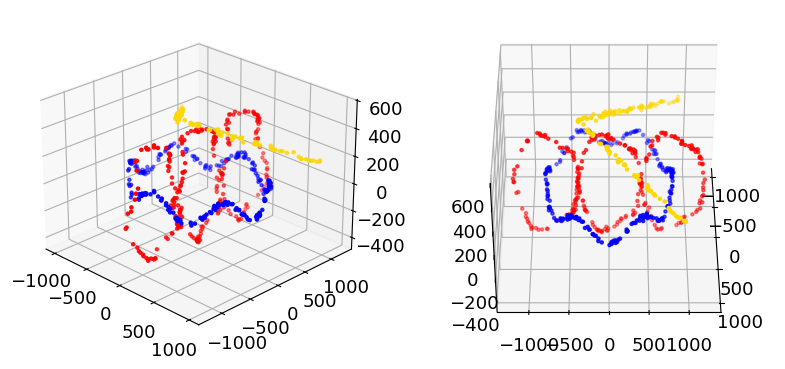

In [2]:
np.random.seed(123)

# number of data samples
N=600
# size of each sample
L=3
LL=12
# rotation
OM  = ortho_group.rvs(dim=L) #random orthogonal matrix for rotation
OMM = ortho_group.rvs(dim=LL) #random orthogonal matrix for rotation of the 12d data
#  % of points in cluster 0 and 1
p0,p1=35,45
# radii for 3d construction
R0=800
R1=400

NOISE=5

x,y,r,noise=np.zeros((N,L)),np.zeros(N),np.random.randint(0,100,N),np.random.randn(N,L)*10
xx,nnoise=np.zeros((N,LL)),np.random.randn(N,LL)*10
X,XX=np.zeros_like(x),np.zeros_like(xx)

for n in range(N):
    if r[n]<p0:
        y[n]=0
        q = random.rand()*2*pi
        x[n,:3] = (R0*cos(q), R0*sin(q), -(R0/10)*cos(6*q)) # trigonometric function
    elif r[n]<p1+p0:
        y[n]=1
        q = random.rand()*2*pi
        x[n,:3] = (-(R1/5)*sin(4*q), R1*cos(q), R1*sin(q)) # trig
        x[n,:3] = x[n,:3] + R0*np.array((0,random.randint(3) - 1, 0))
    else:
        y[n]=2
        q = random.rand()*1000.
        x[n,:3] = ((random.randint(2)-0.5)*2*q, 1.333*q-R1, 1.333*R1-0.333*q) #- linear
    x[n] = x[n]+noise[n]
    xx[n,:3] = x[n] # copy the 3d data to the first 3 dimensions of the 12d data
    nnoise[n,3:] = nnoise[n,3:] * NOISE # add noise to the 12d data
    xx[n] = xx[n] + nnoise[n] # add noise to the 12d data
    X[n] = np.dot(OM,x[n]) # rotate the 3d data
    XX[n] = np.dot(OMM,xx[n]) # rotate the 12d data
y = y.astype(int)

fig = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x[:,0], x[:,1], x[:,2], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(25+15*i, 45*(i-1))
    

plt.draw()

np.savetxt("DATA/x_12d.dat",XX,delimiter='\t')
np.savetxt("DATA/y_12d.dat",y,fmt="%d")

x0=np.copy(x)

In [3]:
# load the data:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


## Find the typical minimum distance between points
This yields a typical scale, to be used as a reference for "eps"

[  0.         145.92274307 161.446568   175.02075719 184.83502833
 186.6121665  187.18824319 219.69258419 224.1511747  242.6862013
 284.09295507] range(0, 599)
(11, 600)


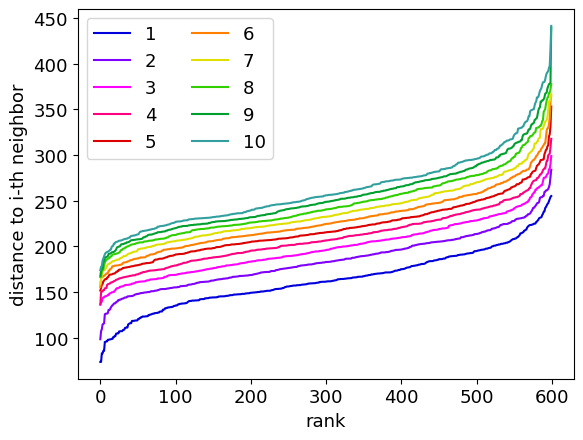

mean minimum distance between nn points:  163.65491354345073


In [4]:
nn = 10
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(x) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(x) # returns distances and indices of nn neighbors
print(d[3,:],range(ind.max()))
dd=d.T # distances to the i-th neighbor for all points, sorted by distance
print(dd.shape)
# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the nearest neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

## Define functions to be used later

In [5]:
# function definitions for later
def entropy(c, n_sample):
    # Measures the Shannon entropy of a cluster
    # c is a dictionary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

# this will only be used to evaluate quality of clustering by looking at predicted vs. true labels:
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments.
        Values from 0 to 1, with 1 being perfect performance.
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

## Visualise DBSCAN best hyperparameters (Exercise 4.1)

In [6]:
# DBSCAN hyperparameter heatmap
np.random.seed(12345)
X = data
y_true = y

# Setting a reasonable range around the mean minimum distance (r)
eps_range = np.linspace(0.1 * mean_min_dist, 2 * mean_min_dist, 60)
min_sample_range = np.arange(1, 50)

eps_data = []
min_sample_range_data = []
nmi_data = []

for eps in eps_range:
    for min_samples in min_sample_range:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        y_hat = model.fit_predict(X)
        
        # Calculate NMI score
        score = NMI(y_true, y_hat)
        
        eps_data.append(eps)
        min_sample_range_data.append(min_samples)
        nmi_data.append(score)

# Reshape to match the heatmap data structure
NMI_grid = np.array(nmi_data).reshape(len(eps_range), len(min_sample_range))

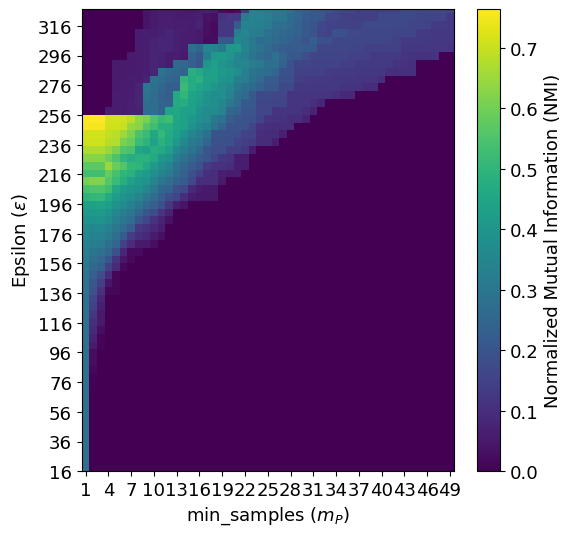

In [7]:
# Plotting the heatmap
plt.figure(figsize=(6, 6))
mesh = plt.pcolormesh(min_sample_range, eps_range, NMI_grid, 
                      shading='auto', cmap='viridis')

plt.colorbar(mesh, label='Normalized Mutual Information (NMI)')
plt.xlabel('min_samples ($m_P$)')
plt.ylabel('Epsilon ($\epsilon$)')
plt.ylim(min(eps_range), max(eps_range))
x_ticks = np.arange(min(min_sample_range), max(min_sample_range) + 1, 3)
y_ticks = np.arange(int(min(eps_range)), int(max(eps_range) + 1), 20)

plt.xticks(x_ticks)
plt.yticks(y_ticks)
plt.show()

### 4.1.1
There seems to be a positive correlation between $ε$ and $mP$ on the global behaviour, while there is a line of abrupt change for a certain threshold for $ε$ for low values of $mP$. This apparent correlation points to a power law relation that defines a density threshold.

### 4.2.2
On the plot it is clear that for certain region of $mP$, the optimal values for $ε$ are right before the threshold, this means that the cluster goes from high-density to sparse background noise. Selecting the value at this point ensures that $ϵ$ is large enough to encompass the $mP$ neighbors shown on the $i$-th neighbor plot.

## Try PCA algorithm on unlabelled dataset (Exercise 4.2)

Let's try PCA on the 12-dimensional dataset: we can exhaust all possibilities by selecting 1, then 2, then..., then all the of the 12 components.

In [8]:
var_list=[]
for i in range(1, data.shape[1]+1):
    #print(i)
    data_reduced = PCA(n_components=i).fit(data)
    var = np.cumsum(data_reduced.explained_variance_ratio_)[-1]
    #print(var)
    var_list.append(var)

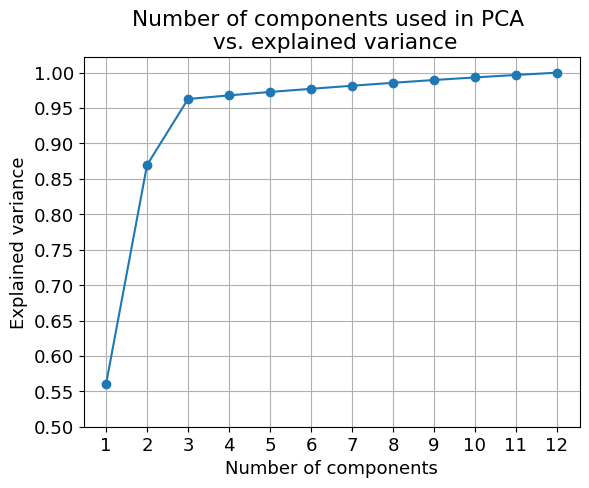

In [9]:
plt.plot(np.arange(1, data.shape[1]+1), var_list, marker='o')
plt.xticks(np.arange(1,12.5,1))
plt.yticks(np.arange(0.5, 1.01, 0.05))  # ticks from 0 to 1 in steps of 0.1
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title("Number of components used in PCA \n vs. explained variance")
plt.grid(True)
plt.show()

We see that for $n_{cps}>3$ (number of selected components), the explained variance stops improving significantly.
Therefore, in the following we choose to select only those three components (which, of course, are a linear combination of all 12 others, selected by the PCA algorithm). Before we do so, however, let's try to see why this is:

Let's select 3 components and visualise the results:

In [10]:
n_cps=3

In [11]:
data_reduced_3=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

In [12]:
print("Original dataset shape:", data.shape)
print("Reduced dataset shape:", data_reduced_3.shape)
#print(data[10:,:])
#print(data_reduced[:10,:])

Original dataset shape: (600, 12)
Reduced dataset shape: (600, 3)


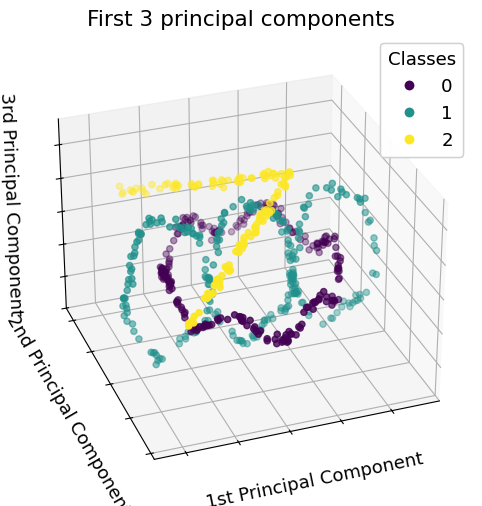

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax.set(
    title=f"First {n_cps} principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend3 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend3)

plt.show()


The three classes appear to be clearly separated at this stage.
(Classes, indicated by different colors, are from the generated data simply for checking performance; our clustering algorithms, like PCA, will *not* be allowed to see them later.)

We now try two components:

In [14]:
n_cps=2
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

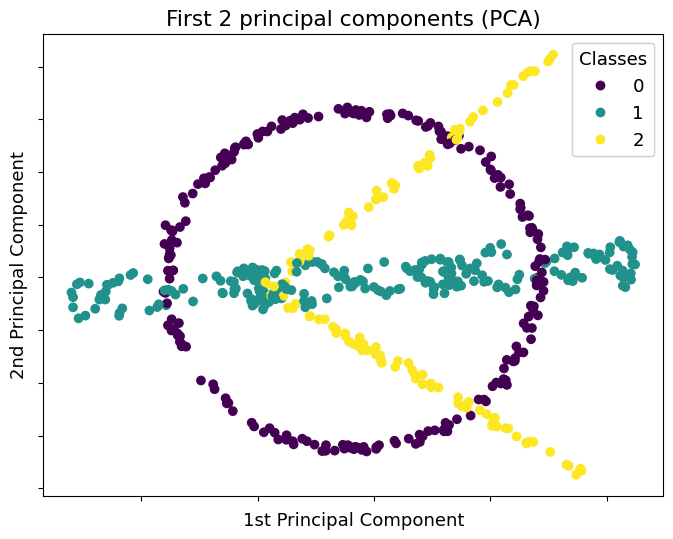

In [15]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    data_reduced[:, 0],
    data_reduced[:, 1],
    c=y
)

ax.set(
    title=f"First {n_cps} principal components (PCA)",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

# Add a legend
legend2 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend2)

plt.show()

We see already that some information would be lost here: some points are overlapping, so no (simple) algorithm would be able to assign them to one cluster or the other.

Let's try one PCA component only:

In [16]:
n_cps=1
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

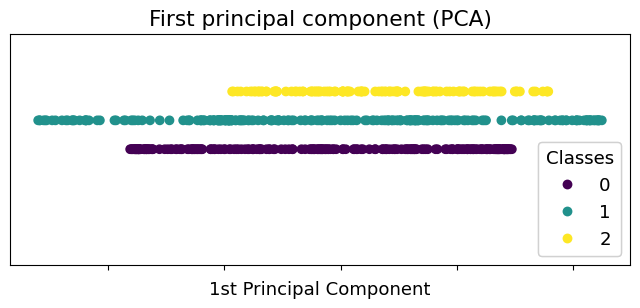

In [17]:
fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    data_reduced[:, 0],
    y=y/4,
    c=y
)

ax.set(
    title="First principal component (PCA)",
    xlabel="1st Principal Component",
    ylim=[-1,1]
)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.yaxis.set_ticks([])

legend1 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="lower right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

As expected, in 1-d most points would be overlapping (the vertical separation here was only introduced for better visualisation), so it would be impossible to classify most of them correctly.

## Try K-means clustering algo on dataset (Exercise 4.3)

We fix the number of clusters $k=3$. We perform PCA beforehand, in order to make sure that the K-means algorithm doesn't worry about the noisy, insignificant components when drawing clusters.

In [18]:
print("Input shape:", data_reduced_3.shape) #  check shape of data that will be used here

Input shape: (600, 3)


In [19]:
kmeans=KMeans(n_clusters=3, init='random', n_init=10, max_iter=300, tol=0.0001, verbose=0, algorithm='lloyd').fit(data_reduced_3)
y_hat=kmeans.labels_
centroids=kmeans.cluster_centers_

In [20]:
y_hat=kmeans.predict(data_reduced_3)
nmi=NMI(y_hat, y)
print("Final NMI:", nmi)

Final NMI: 0.1262461683689528


C:\Users\Libero\AppData\Local\Temp\ipykernel_12348\2017230315.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


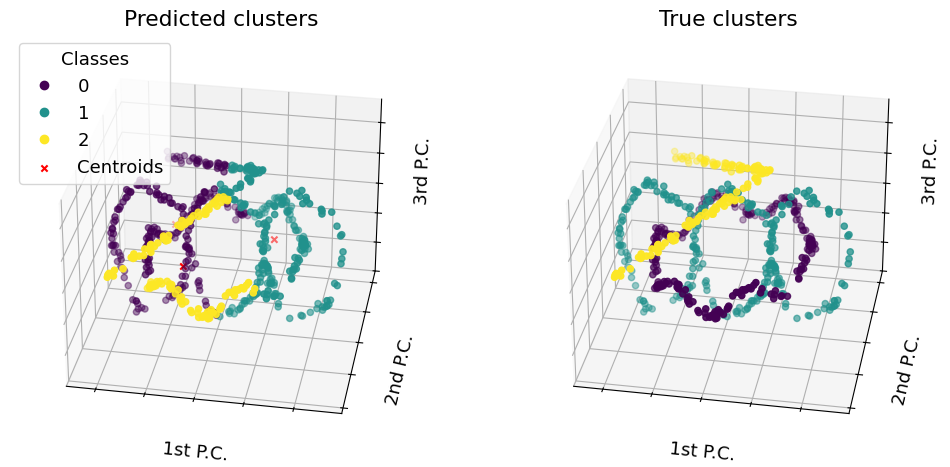

In [21]:
# plot results:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

scatter1b=ax1.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='x', c='r', label="Centroids")

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter1b)
labels1.append("Centroids")
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

plt.tight_layout()
plt.show()

As expected, results are poor: the clusters have shapes that are far from being round or compact, so centroids-based methods are bound to fail.

## Try hierarchical clustering (Exercise 4.4)

As before, we performed PCA beforehand. Here we also standardise the data (ie, mean 0 and STD 1) for better performance:

In [22]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data_reduced_3) 

### Compare different metrics and linkages to find best output

We try all possible "linkages" (ie. the quantity to minimise) and metrics (ie. the actual definition of "distance" between any two points) already implemented in this ScikitLearn function:

In [23]:
my_linkages=['ward', 'complete', 'average', 'single']
my_metrics=['euclidean', 'l1', 'l2', 'manhattan', 'cosine']

best_model=''
scores=[]
models=[]
score_best=-1e9
for mc in my_metrics:
    for lk in my_linkages:
        if ((lk=='ward') and (mc!='euclidean')): continue # these are incompatible by definition
        hc_model=HC(n_clusters=3, metric=mc, linkage=lk, compute_distances=True)
        cluster_labels = hc_model.fit_predict(scaled_data)
        sil_score = silhouette_score(scaled_data, cluster_labels)
        if (sil_score>score_best):
            score_best=sil_score
            best_model=hc_model
        scores.append(sil_score)

In [24]:
print('Best "silhouette" score:', score_best, '\n')
print("Best model:", best_model, '\n')

y_hat=best_model.labels_
nmi=NMI(y_hat, y)
print("Best NMI:", nmi)

Best "silhouette" score: 0.27899310356666435 

Best model: AgglomerativeClustering(compute_distances=True, linkage='average',
                        metric='cosine', n_clusters=3) 

Best NMI: 0.25158051075398297


As we can see, results although still poor have slightly improved; this is probably due to the fact that hierarchical clustering, being a density-based method, is more appropriate for clusters of complex shape. However, this method (like the ones before) does not distinguish different "shapes" of the data.

### Visualise the dendrogram
(for the best model obtained).

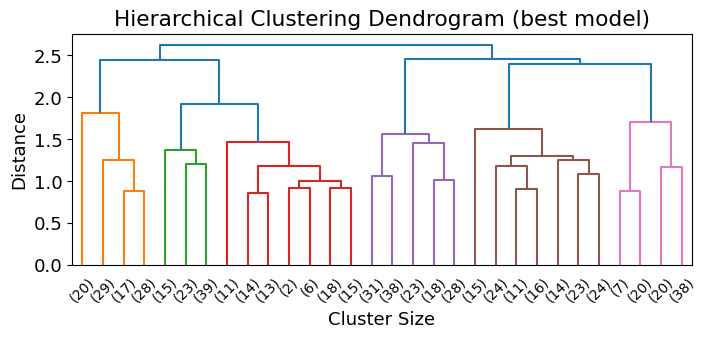

In [25]:
linked = linkage(scaled_data, method='average')

plt.figure(figsize=(8, 3))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)
plt.title("Hierarchical Clustering Dendrogram (best model)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

C:\Users\Libero\AppData\Local\Temp\ipykernel_12348\261819132.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


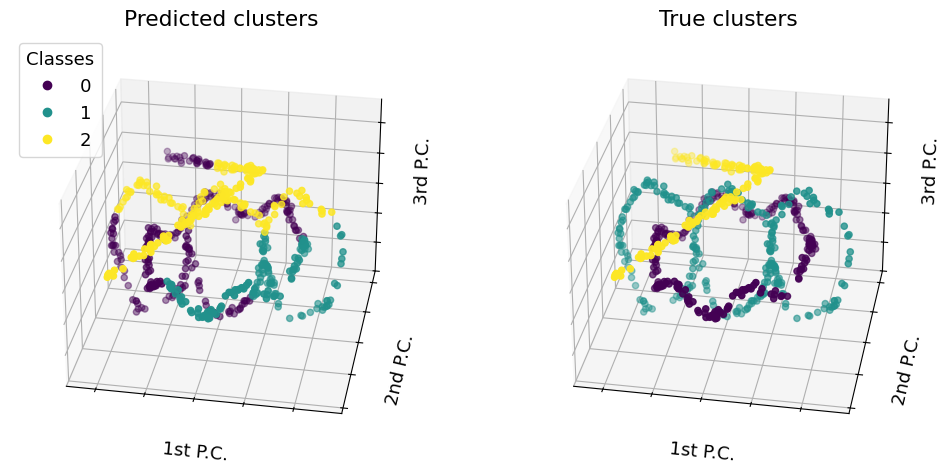

In [26]:
# plot the results in 3-d space:

fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

plt.tight_layout()
plt.show()

### Try spectral clustering (Exercise 4.5)

We try yet another clustering method, which performs clustering (eg. with K-means) on a *map* of the original data (a projection of the normalized Laplacian), to distinguish clusters by their characteristic shape. As before, we perform PCA beforehand.

The mapping (ie, the first and most important part of the algorithm) is realised by means of a simple linear algebra algorithm which involves solving a generalised eigenvalues problems (hence the name "spectral"); however, its justification is far from being trivial and relies on Graph Theory concepts and theorems. We can say, harshly over-simplifying, that this algorithm treats the data points as if belonging to a (in general multi-dimensional) manifold, and looks at its Laplacian (ie, how fast the gradient varies on this surface) to understand if a point belongs to the same clusters as the others close it or not: we expect the gradient to be almost constant between nearby points belonging to the same cluster.

As in the previous exercise, we use 3-dimensional standardised data.

In [27]:
def remap_labels(y_true, y_pred):
    # function to remap predicted lables as to align them with the true ones (used later for plotting)
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)  # maximize overlap
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[label] for label in y_pred])

Here we construct the so called "affinity matrix" $W$ (first part of the algorithm) by means of a Gaussian kernel, varying its "gamma" parameter. This method is more elaborate and therefore more computationally heavy, as for each couple of points we have:

$W_{ij} = \exp\left(-\gamma \|x_i - x_j\|^2\right)$

In [28]:
gammas=[0.001,0.01,0.1,1,10,100]
nmi_list=[]
nmi_best=-0.1
gamma_best=0

start=time()
# rbf kernel with different gammas
for g in gammas:
    y_hat=SC(n_clusters=3,
       n_init=10, # number of iters for assigning_labels='kmeans'
       gamma=g, # kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels
       eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
       affinity='rbf', # kernel to use to calculate the affinity matrix
       n_neighbors=10, # for nearest-neighbor method of assigning labels
       eigen_tol='auto', # eigen_tol=0.0 for arpack
       assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
       degree=3, # degree for poly kernel only
       coef0=1, # for poly and sigmoid kernels only
       verbose=False).fit_predict(scaled_data)
    nmi=NMI(y_hat,y)
    if (nmi>nmi_best):
        nmi_best=nmi
        gamma_best=g
    nmi_list.append(nmi)
end=time()
tot_time=end-start
print("Computational time:", tot_time, "s")

Computational time: 45.20468735694885 s


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[4.22669475e-15 3.57686638e-06 3.51966134e-06 2.38796069e-05]
not reaching the requested tolerance 8.940696716308594e-06.
Use iteration 1691 instead with accuracy 
5.637384063167861e-06.

  _, diffusion_map = lobpcg(
C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[3.84171326e-15 2.93306118e-06 3.26917690e-06 1.63472977e-05]
not reaching the requested tolerance 8.940696716308594e-06.
  _, diffusion_map = lobpcg(


In [29]:
print("Best NMI:", nmi_best)
print("Best gamma parameter:", gamma_best)

Best NMI: 0.5294881695975526
Best gamma parameter: 100


Results are better, but still pretty bad. We try a more naive way of constructing the affinity matrix, ie. a matrix with entries either 1 or 0 for every couple of points, respectively if a point is amont the $k$ nearest neighbors or the other or not:

$W_{ij} = \begin{cases} 1 & \text{if } x_i \in \text{kNN}(x_j) \text{ or } x_j \in \text{kNN}(x_i) \\ 0 & \text{otherwise} \end{cases}$

In [30]:
# nearest neighbors kernel
y_hat=SC(n_clusters=3,
   n_init=10, # number of iters for assigning_labels='kmeans'
   eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
   affinity='nearest_neighbors', # kernel to use to calculate the affinity matrix
   n_neighbors=10, # for nearest-neighbor method of assigning labels
   eigen_tol='auto', # eigen_tol=0.0 for arpack
   assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
   verbose=False).fit_predict(scaled_data)
nmi=NMI(y_hat,y)
print("Best NMI:", nmi)

Best NMI: 0.9617394647100065


This achieves very good NMI, very fast!

Let's plot these results (after remapping labels to get a proper plot):

In [31]:
y_hat = remap_labels(y, y_hat)

C:\Users\Libero\AppData\Local\Temp\ipykernel_12348\2331600846.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


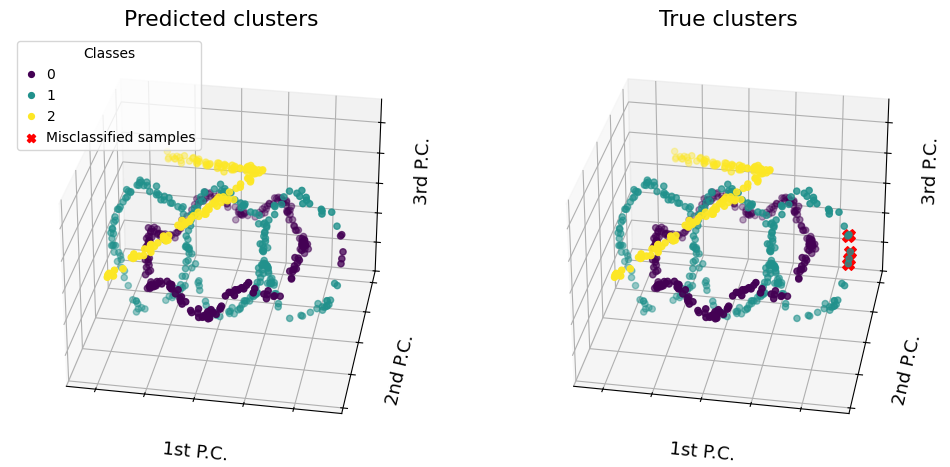

In [37]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2, projection="3d", elev=-150, azim=80)

scatter1 = ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)
ax1.set(title="Predicted clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True)
ax2.set(title="True clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

miscl_mask = [y_hat != y]
scatter3 = ax2.scatter(
    data_reduced_3[miscl_mask[0], 0],
    data_reduced_3[miscl_mask[0], 1],
    data_reduced_3[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    label='Misclassified samples')

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter3)
labels1.append('Misclassified samples')
ax1.legend(handles1, labels1, title="Classes", loc="upper left",
           fontsize=10, title_fontsize=10, markerscale=0.7,
           handlelength=1.2, handletextpad=0.5, borderpad=0.4) # for smaller legend

plt.tight_layout()
plt.show()

Let's repeat the first part of the algorithm to see on which space the k-clustering is actually separating the points:

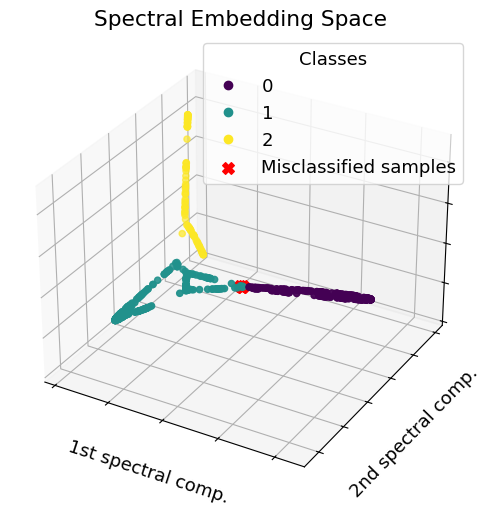

In [33]:
#visualise the embedding space:

se = SE(n_components=3, affinity='nearest_neighbors', n_neighbors=10) # exactly the same algorithm used inside SC 
embedding = se.fit_transform(scaled_data)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
scatter=ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], c=y)
scatter_m = ax.scatter(
    embedding[miscl_mask[0], 0],
    embedding[miscl_mask[0], 1],
    embedding[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    label='Misclassified samples')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set(title="Spectral Embedding Space", xlabel="1st spectral comp.", ylabel="2nd spectral comp.", zlabel="3rd spectral comp.")
handles, labels = scatter.legend_elements()
handles.append(scatter_m)
labels.append('Misclassified samples')

ax.legend(handles, labels, title="Classes", loc="upper right")
plt.show()

As we can see, points in this embedding space are very clearly separated; only a few misclassified samples lie between two of the clusters.